In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
conn = sqlite3.connect(r"C:\Users\DeLL\OneDrive\New folder\olist.db")

# Example: load orders
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('fact_order_items',), ('fact_payments',), ('fact_reviews',), ('dim_customers',), ('dim_products',), ('dim_sellers',), ('dim_calendar',), ('dim_orders',)]


In [3]:
orders = pd.read_sql("SELECT * FROM dim_orders;", conn)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()
orders.isnull().sum()
orders.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


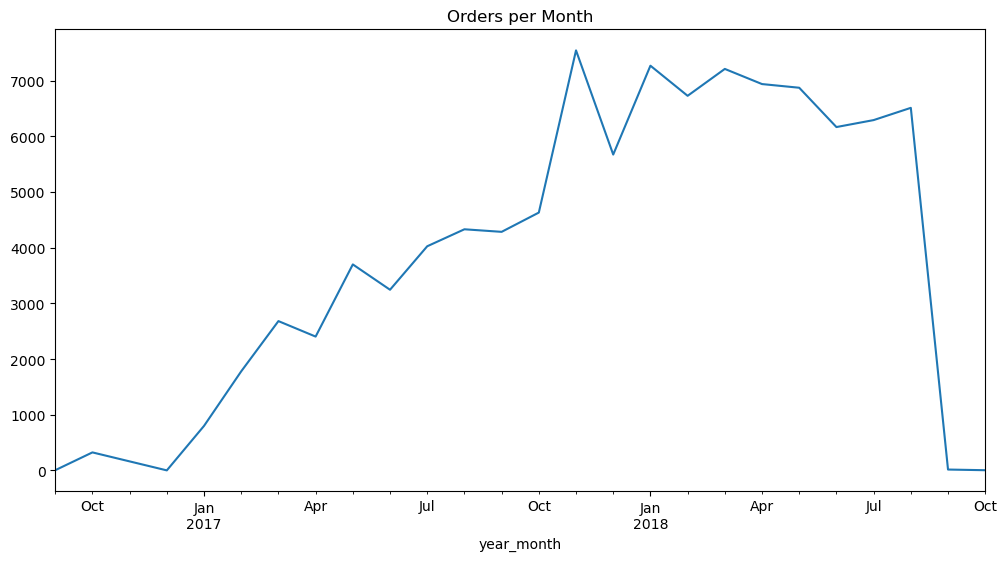

In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('year_month').size()
monthly_orders.plot(kind="line", figsize=(12,6), title="Orders per Month")
plt.show()


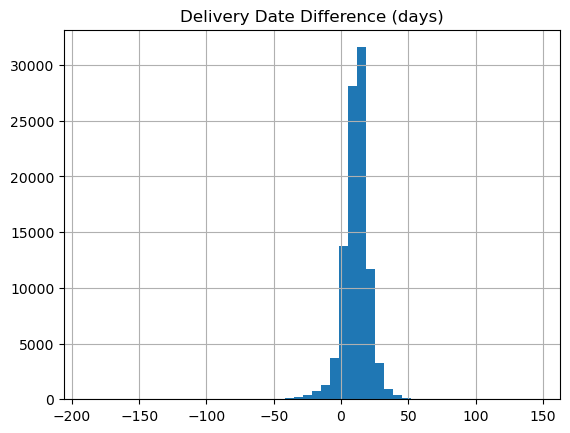

In [7]:
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

orders['delivery_diff'] = (orders['order_estimated_delivery_date'] - orders['order_delivered_customer_date']).dt.days
orders['delivery_diff'].hist(bins=50)
plt.title("Delivery Date Difference (days)")
plt.show()


# Payment data


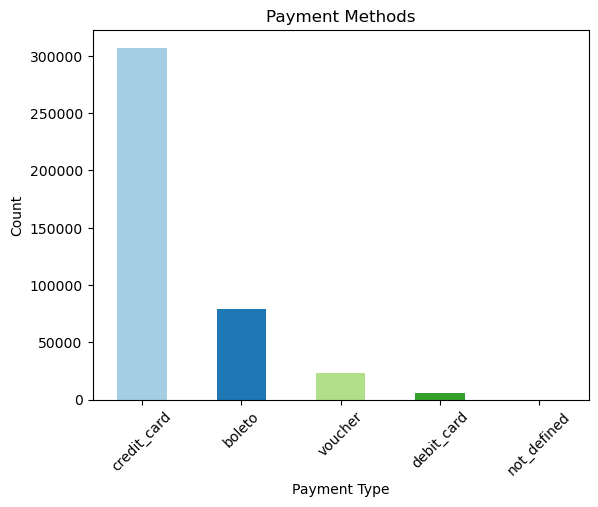

In [9]:
payments = pd.read_sql("SELECT * FROM fact_payments;", conn)
counts = payments['payment_type'].value_counts()
counts.plot(kind="bar", 
            title="Payment Methods", 
            color=plt.cm.Paired.colors)  # or plt.cm.Set2.colors
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# reviews

<Axes: title={'center': 'Review Scores Distribution'}, xlabel='review_score'>

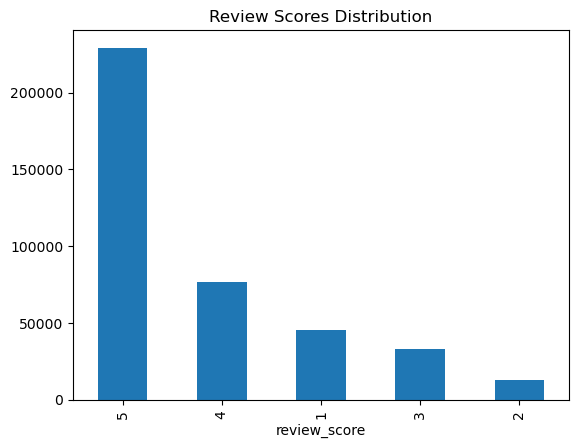

In [11]:
reviews = pd.read_sql("SELECT * FROM fact_reviews;", conn)
reviews['review_score'].value_counts().plot(kind="bar", title="Review Scores Distribution")


# GMV Gross merchandise value

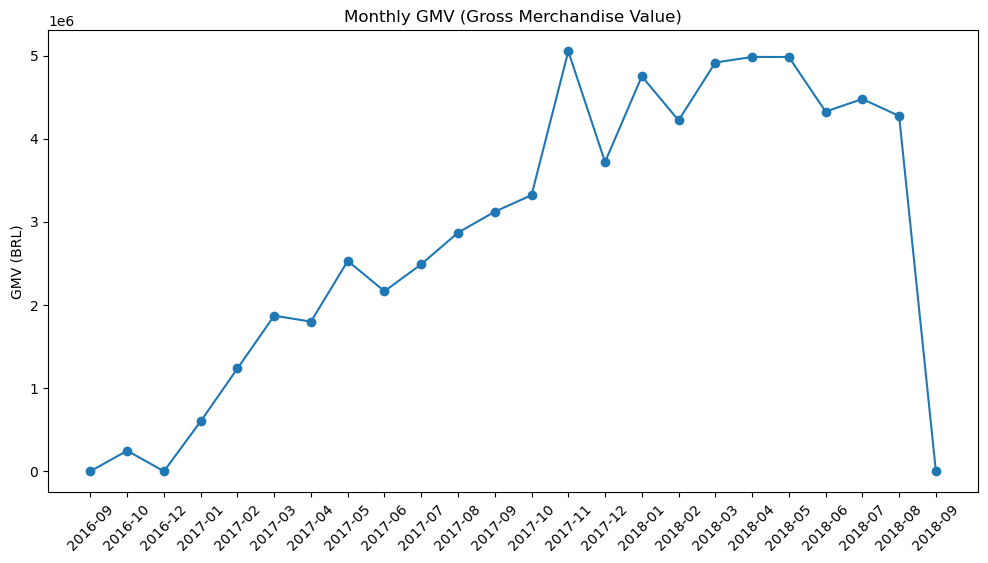

In [13]:
gmv = pd.read_sql("""
    SELECT 
        strftime('%Y-%m', o.order_purchase_timestamp) AS year_month,
        SUM(oi.price) AS gmv
    FROM fact_order_items oi
    JOIN dim_orders o ON oi.order_id = o.order_id
    GROUP BY year_month
    ORDER BY year_month;
""", conn)

plt.figure(figsize=(12,6))
plt.plot(gmv['year_month'], gmv['gmv'], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly GMV (Gross Merchandise Value)")
plt.ylabel("GMV (BRL)")
plt.show()


# top product categories by revenue

In [29]:
pd.read_sql("PRAGMA table_info(dim_products);", conn)


,cid,name,type,notnull,dflt_value,pk
0,0,product_id,TEXT,0,None,0
1,1,product_category_name,TEXT,0,None,0
2,2,product_name_length,INTEGER,0,None,0
3,3,product_description_length,INTEGER,0,None,0
4,4,product_photos_qty,INTEGER,0,None,0
5,5,product_weight_g,REAL,0,None,0
6,6,product_length_cm,REAL,0,None,0
7,7,product_height_cm,REAL,0,None,0
8,8,product_width_cm,REAL,0,None,0


C:\Users\DeLL\AppData\Local\Temp\ipykernel_21900\2599978341.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="revenue", y="category", data=top_categories, palette="Blues_r")


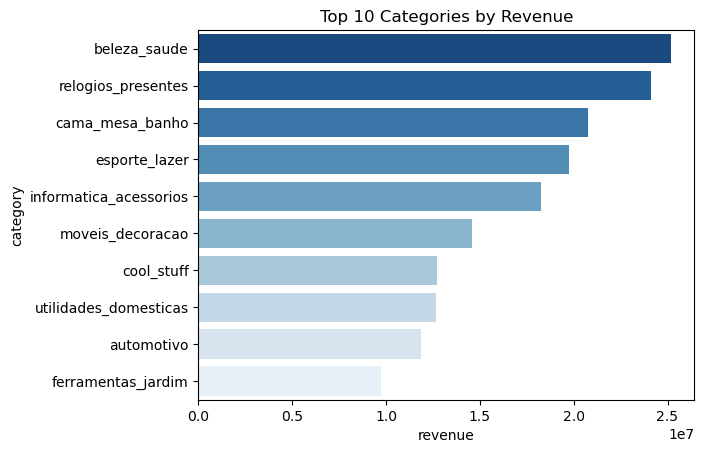

In [31]:
top_categories = pd.read_sql("""
    SELECT 
        p.product_category_name AS category,
        ROUND(SUM(oi.price),2) AS revenue
    FROM fact_order_items oi
    JOIN dim_products p ON oi.product_id = p.product_id
    GROUP BY category
    ORDER BY revenue DESC
    LIMIT 10;
""", conn)

sns.barplot(x="revenue", y="category", data=top_categories, palette="Blues_r")
plt.title("Top 10 Categories by Revenue")
plt.show()


In [39]:
category_translation = {
    'beleza_saude': 'Beauty & Health',
    'relogios_presentes': 'watches presents',
    'informatica_acessorios': 'Computer Accessories',
    'cama_mesa_banho': 'Bed Bath & Table',
    'moveis_decoracao': 'Furniture & Decor',
    'brinquedos': 'Toys',
    'esporte_lazer': 'sports leisure',
    'eletronicos': 'Electronics',
    'perfumaria': 'Perfumery',
    'automotivo': 'automotive',
    'utilidades_domesticas': 'domestic utilities',
    'ferramentas_jardim': 'garden tool'
    # Add more as needed
}


In [41]:
top_categories['category_english'] = top_categories['category'].map(category_translation).fillna(top_categories['category'])


C:\Users\DeLL\AppData\Local\Temp\ipykernel_21900\3526642247.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


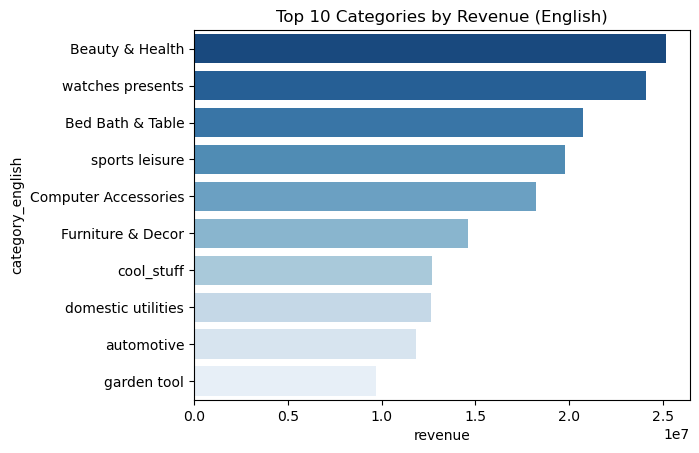

In [43]:
sns.barplot(
    x="revenue", 
    y="category_english", 
    data=top_categories, 
    palette="Blues_r"
)
plt.title("Top 10 Categories by Revenue (English)")
plt.show()


# top  sellers by revenue

In [48]:
pd.read_sql("PRAGMA table_info(dim_sellers);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,seller_id,TEXT,0,None,0
1,1,seller_zip_code_prefix,TEXT,0,None,0
2,2,seller_city,TEXT,0,None,0
3,3,seller_state,TEXT,0,None,0


In [50]:
top_sellers = pd.read_sql("""
    SELECT 
        s.seller_id,
        s.seller_city,
        s.seller_state,
        ROUND(SUM(oi.price),2) AS revenue
    FROM fact_order_items oi
    JOIN dim_sellers s ON oi.seller_id = s.seller_id
    GROUP BY s.seller_id, s.seller_city, s.seller_state
    ORDER BY revenue DESC
    LIMIT 10;
""", conn)


top_sellers['seller_label'] = top_sellers['seller_city'] + ", " + top_sellers['seller_state']


C:\Users\DeLL\AppData\Local\Temp\ipykernel_21900\3350135274.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="revenue", y="seller_label", data=top_sellers, palette="Greens_r")


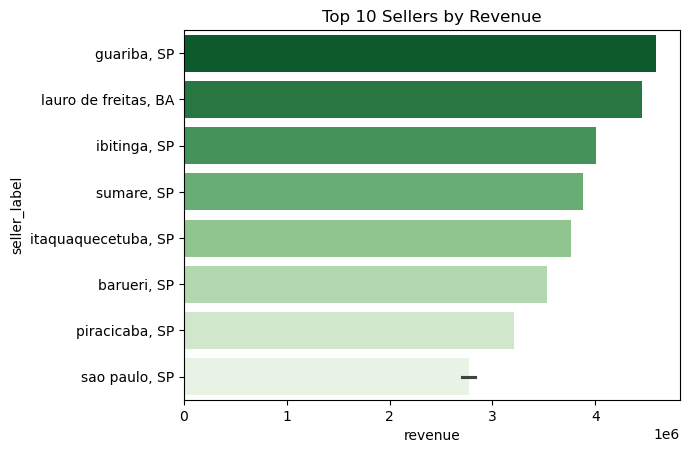

In [52]:

sns.barplot(x="revenue", y="seller_label", data=top_sellers, palette="Greens_r")
plt.title("Top 10 Sellers by Revenue")
plt.show()

In [56]:
#recency frequency of customers
import datetime as dt

# Load orders + payments
orders = pd.read_sql("SELECT * FROM dim_orders;", conn)
order_items = pd.read_sql("SELECT * FROM fact_order_items;", conn)

# Convert dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
snapshot_date = orders['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Aggregate
rfm = (orders.groupby('customer_id')
       .agg({
           'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,  # Recency
           'order_id': 'count'                                                  # Frequency
       })
       .rename(columns={'order_purchase_timestamp': 'Recency',
                        'order_id': 'Frequency'}))

# Add monetary from order_items
monetary = (order_items.groupby('order_id')['price'].sum()
            .reset_index()
            .merge(orders[['order_id','customer_id']], on='order_id')
            .groupby('customer_id')['price'].sum())

rfm['Monetary'] = monetary
rfm.head()


,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,338,1,449.00
000161a058600d5901f007fab4c27140,459,1,274.50
0001fd6190edaaf884bcaf3d49edf079,597,1,899.95
0002414f95344307404f0ace7a26f1d5,428,1,749.50
000379cdec625522490c315e70c7a9fb,199,1,465.00


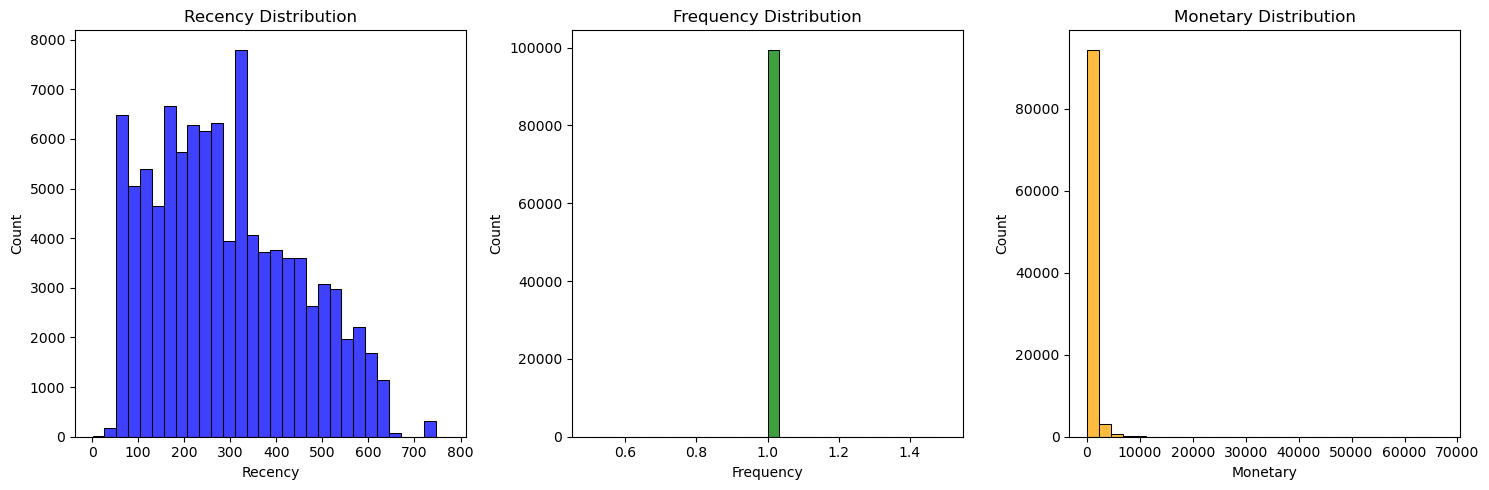

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='blue')
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='green')
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color='orange')
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\base.py:568: RuntimeWarning: invalid value encountered in cast
  result = np.asarray(self, dtype=dtype)
C:\Users\DeLL\AppData\Local\Temp\ipykernel_21900\3612137341.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rfm_segment = rfm.groupby(['R_Score', 'F_Score']).size().unstack()


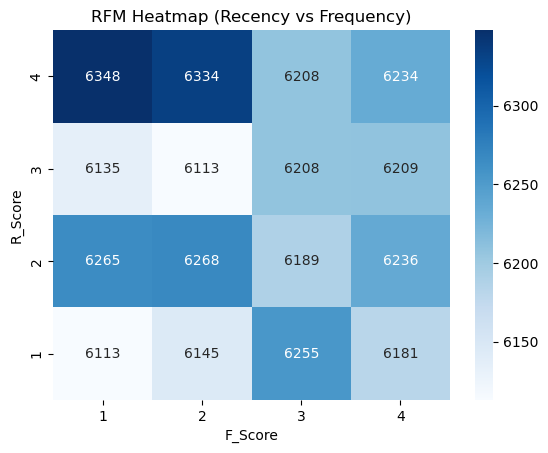

In [60]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1).astype(int)

rfm_segment = rfm.groupby(['R_Score', 'F_Score']).size().unstack()
sns.heatmap(rfm_segment, cmap="Blues", annot=True, fmt="d")
plt.title('RFM Heatmap (Recency vs Frequency)')
plt.show()
